<a href="https://colab.research.google.com/github/MegaDeadCowboy/jasper-burn-severity/blob/main/notebooks/05_beetle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup

In [14]:
![ -d /content/jasper-burn-severity ] || git clone https://github.com/MegaDeadCowboy/jasper-burn-severity.git /content/jasper-burn-severity
%cd /content/jasper-burn-severity
!pip install -q rioxarray geopandas pystac-client planetary-computer stackstac

/content/jasper-burn-severity


In [15]:
import sys; sys.path.insert(0, ".")
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, rioxarray
import pystac_client, planetary_computer
import logging; logging.getLogger("rasterio._env").setLevel(logging.ERROR)
try:
    from google.colab import drive; drive.mount("/content/drive")
    DATA = Path("/content/drive/MyDrive/jasper-burn-severity/data")
except ImportError:
    DATA = Path("data")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

UTM, BUFFER_M = 32611, 2000
for f in ["dnbr_2023_2025.tif", "s2_pre_2023.tif", "nbac_jasper_2024.gpkg"]:
    assert (DATA / f).exists(), f"missing {f}: run 01 and 02 first"
perim = gpd.read_file(DATA / "nbac_jasper_2024.gpkg").to_crs(UTM)
BBOX = perim.buffer(BUFFER_M).to_crs(4326).total_bounds.tolist()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Landsat Scene Search

In [19]:
cat = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
                                modifier=planetary_computer.sign_inplace)

def search(dt):
    return cat.search(collections=["landsat-c2-l2"], bbox=BBOX, datetime=dt,
                      query={"platform": {"in": ["landsat-8", "landsat-9"]},
                             "landsat:collection_category": {"eq": "T1"}}).item_collection()

WINDOWS = {"base": ["2013-07-01/2013-08-31", "2014-07-01/2014-08-31"],
           "2023": ["2023-07-01/2023-08-31"]}
items = {k: [i for dt in v for i in search(dt)] for k, v in WINDOWS.items()}
scenes = pd.DataFrame([dict(year=y, id=i.id, date=i.datetime.date(),
                            platform=i.properties["platform"],
                            path_row=f'{i.properties["landsat:wrs_path"]}/{i.properties["landsat:wrs_row"]}',
                            cloud=i.properties["eo:cloud_cover"])
                       for y, ic in items.items() for i in ic]).sort_values(["year", "date"])
print(scenes.groupby("year").agg(n=("id", "size"), path_rows=("path_row", lambda s: sorted(set(s)))))
scenes

       n                             path_rows
year                                          
2023  26  [044/023, 044/024, 045/023, 046/023]
base  30  [044/023, 044/024, 045/023, 046/023]


,year,id,date,platform,path_row,cloud
54,2023,LC08_L2SP_044024_20230701_02_T1,2023-07-01,landsat-8,044/024,36.38
55,2023,LC08_L2SP_044023_20230701_02_T1,2023-07-01,landsat-8,044/023,88.51
53,2023,LC09_L2SP_046023_20230707_02_T1,2023-07-07,landsat-9,046/023,17.02
52,2023,LC08_L2SP_045023_20230708_02_T1,2023-07-08,landsat-8,045/023,15.23
50,2023,LC09_L2SP_044024_20230709_02_T1,2023-07-09,landsat-9,044/024,28.84
51,2023,LC09_L2SP_044023_20230709_02_T1,2023-07-09,landsat-9,044/023,18.45
49,2023,LC08_L2SP_046023_20230715_02_T1,2023-07-15,landsat-8,046/023,68.40
48,2023,LC09_L2SP_045023_20230716_02_T1,2023-07-16,landsat-9,045/023,29.37
46,2023,LC08_L2SP_044024_20230717_02_T1,2023-07-17,landsat-8,044/024,90.59
47,2023,LC08_L2SP_044023_20230717_02_T1,2023-07-17,landsat-8,044/023,92.99


2. Landsat NDVI Composites (2013,2023)

In [20]:
import stackstac
from rasterio.enums import Resampling

d = rioxarray.open_rasterio(DATA / "dnbr_2023_2025.tif", masked=True).squeeze("band", drop=True)
assert d.rio.crs.to_epsg() == UTM and d.rio.resolution() == (20.0, -20.0)
GRID = dict(epsg=UTM, resolution=20, bounds=d.rio.bounds(), snap_bounds=False,
            xy_coords="center", chunksize=1024)
BAD_BITS = 0b111111   # QA_PIXEL bits 0–5: fill, dilated cloud, cirrus, cloud, shadow, snow

def ndvi_composite(ic):
    refl = stackstac.stack(ic, assets=["red", "nir08"], resampling=Resampling.bilinear,
                            dtype="float32", fill_value=np.float32(np.nan), rescale=False, **GRID)
    qa = stackstac.stack(ic, assets=["qa_pixel"], resampling=Resampling.nearest,
                         dtype="uint16", fill_value=np.uint16(1), rescale=False, **GRID).sel(band="qa_pixel")
    raw_ok = (refl > 0).all("band")                      # DN 0 = nodata
    refl = refl * 2.75e-5 - 0.2                          # C2 L2 SR scale/offset (from STAC raster:bands)
    red, nir = refl.sel(band="red"), refl.sel(band="nir08")
    ok = ((qa & BAD_BITS) == 0) & raw_ok & (red > 0) & (nir > 0)
    v = ((nir - red) / (nir + red)).where(ok).chunk(time=-1)
    out = xr.Dataset({"ndvi": v.median("time", skipna=True), "n_clear": ok.sum("time")}).compute()
    out = out.reset_coords(drop=True).rio.write_crs(UTM)
    assert np.allclose(out.x, d.x) and np.allclose(out.y, d.y), "grid mismatch vs dNBR"
    return out

In [23]:
import xarray as xr
ls = {y: ndvi_composite(ic) for y, ic in items.items()}

for y, ds in ls.items():
    inside = ds.rio.clip(perim.geometry, drop=False)
    n = inside.n_clear.values[np.isfinite(inside.ndvi.values) | (inside.n_clear.values == 0)]
    v = inside.ndvi.values[np.isfinite(inside.ndvi.values)]
    print(f"{y}: clear obs/pixel min {n.min()} / median {np.median(n):.0f}; "
          f"zero-clear {np.mean(n == 0):.1%}; NDVI median {np.median(v):.3f}")
    ds.ndvi.rio.to_raster(DATA / f"ls_ndvi_{y}.tif", compress="deflate")
    ds.n_clear.astype("uint8").rio.to_raster(DATA / f"ls_nclear_{y}.tif", compress="deflate")

/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/usr/local/lib/python3.13/dist-packages/xarray/core/duck_array_ops.py:277: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


base: clear obs/pixel min 0 / median 3; zero-clear 0.8%; NDVI median 0.709


/usr/local/lib/python3.13/dist-packages/xarray/core/duck_array_ops.py:277: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


2023: clear obs/pixel min 1 / median 3; zero-clear 0.0%; NDVI median 0.638


03. The Mortality Proxy

In [24]:
from rasterio.features import rasterize
from src.indices import ndvi

BANDS = ["B04", "B08", "B8A", "B12"]
pre = rioxarray.open_rasterio(DATA / "s2_pre_2023.tif", masked=True).assign_coords(band=BANDS).to_dataset("band")
veg = (ndvi(pre) >= 0.10).values                                   # adopted pre-fire veg mask
IN = rasterize(perim.geometry, out_shape=d.shape, transform=d.rio.transform()).astype(bool)
ring_geom = perim.buffer(BUFFER_M).difference(perim.union_all())
RING = rasterize(ring_geom.geometry, out_shape=d.shape, transform=d.rio.transform()).astype(bool)

mort = (ls["base"].ndvi - ls["2023"].ndvi).rename("ndvi_decline")  # + = canopy loss 2013–14 → 2023
ok = veg & np.isfinite(mort.values) & np.isfinite(d.values)

for name, zone in [("inside perimeter", IN), ("2 km ring", RING)]:
    m = mort.values[zone & ok]
    print(f"{name}: n={m.size:,} ({m.size*0.04:,.0f} ha)  median {np.median(m):.3f}  "
          f"p5 {np.percentile(m,5):.3f}  p95 {np.percentile(m,95):.3f}  >0.10: {np.mean(m > 0.10):.1%}")
print(f"inside perimeter dropped (no Landsat obs or non-veg): {1 - (IN & ok).sum()/IN.sum():.1%}")

mort.rio.write_crs(UTM).rio.to_raster(DATA / "ndvi_decline_2013-14_2023.tif", compress="deflate")

/tmp/ipykernel_2396/2065827215.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring_geom = perim.buffer(BUFFER_M).difference(perim.unary_union)


inside perimeter: n=780,582 (31,223 ha)  median 0.055  p5 -0.049  p95 0.155  >0.10: 22.1%
2 km ring: n=594,298 (23,772 ha)  median 0.033  p5 -0.050  p95 0.146  >0.10: 17.6%
inside perimeter dropped (no Landsat obs or non-veg): 1.3%


04. Mortality vs severity

In [25]:
from scipy.stats import spearmanr

sel = IN & ok
r, c = np.nonzero(sel)
df = pd.DataFrame({"mort": mort.values[sel], "dnbr": d.values[sel],
                   "pre_ndvi": ndvi(pre).values[sel], "blk": (r // 50) * 10_000 + (c // 50)})

rho_px = spearmanr(df.mort, df.dnbr).statistic
g = df.groupby("blk").agg(mort=("mort", "median"), dnbr=("dnbr", "median"), n=("mort", "size"))
g = g[g.n >= 1250]                                   # ≥ half a 1 km block (50×50 px) valid
rho_blk, p_blk = spearmanr(g.mort, g.dnbr)
print(f"pixel Spearman rho {rho_px:.3f} (n={len(df):,});  1 km blocks rho {rho_blk:.3f}, p={p_blk:.2g} (n={len(g)})")

df["pre_q"] = pd.qcut(df.pre_ndvi, 5, labels=False)
strat = df.groupby("pre_q").apply(lambda s: pd.Series({
    "pre_ndvi_med": s.pre_ndvi.median(), "n": len(s),
    "rho": spearmanr(s.mort, s.dnbr).statistic}), include_groups=False)
print(strat.round(3))

df["mort_dec"] = pd.qcut(df.mort, 10, labels=False)
dec = df.groupby("mort_dec").agg(mort_med=("mort", "median"), dnbr_med=("dnbr", "median"),
                                 high_pct=("dnbr", lambda s: (s > 0.66).mean()))
print(dec.round(3))

pixel Spearman rho -0.082 (n=780,582);  1 km blocks rho -0.164, p=0.0029 (n=328)
       pre_ndvi_med         n    rho
pre_q                               
0             0.498  156117.0  0.249
1             0.560  156117.0 -0.085
2             0.595  156117.0 -0.104
3             0.629  156114.0 -0.144
4             0.681  156117.0 -0.143
          mort_med  dnbr_med  high_pct
mort_dec                              
0           -0.049     0.522     0.294
1           -0.007     0.532     0.296
2            0.016     0.552     0.312
3            0.033     0.560     0.293
4            0.048     0.550     0.264
5            0.062     0.532     0.232
6            0.076     0.526     0.228
7            0.094     0.527     0.237
8            0.117     0.506     0.204
9            0.155     0.436     0.121


In [26]:
from src.indices import nbr

df["nbr_pre"] = nbr(pre).values[sel]
df = df[np.abs(df.nbr_pre) >= 0.05].copy()            # avoid blow-up near NBR_pre = 0
df["rdnbr"] = df.dnbr / np.sqrt(np.abs(df.nbr_pre))

g = df.groupby("blk").agg(mort=("mort", "median"), rdnbr=("rdnbr", "median"), n=("mort", "size"))
g = g[g.n >= 1250]
rho_blk, p_blk = spearmanr(g.mort, g.rdnbr)
print(f"RdNBR: pixel rho {spearmanr(df.mort, df.rdnbr).statistic:.3f} (n={len(df):,});  "
      f"1 km blocks rho {rho_blk:.3f}, p={p_blk:.2g} (n={len(g)})")
print(df.groupby("pre_q").apply(lambda s: spearmanr(s.mort, s.rdnbr).statistic,
                                include_groups=False).round(3).rename("rho_rdnbr"))
print(df.groupby("mort_dec").agg(mort_med=("mort", "median"),
                                 rdnbr_med=("rdnbr", "median")).round(3))

RdNBR: pixel rho -0.000 (n=775,694);  1 km blocks rho -0.084, p=0.13 (n=327)
pre_q
0    0.171
1   -0.040
2   -0.030
3   -0.045
4   -0.069
Name: rho_rdnbr, dtype: float64
          mort_med  rdnbr_med
mort_dec                     
0           -0.049      0.866
1           -0.007      0.886
2            0.016      0.909
3            0.033      0.921
4            0.048      0.915
5            0.062      0.901
6            0.076      0.892
7            0.094      0.895
8            0.117      0.883
9            0.155      0.819


05. *Figure*

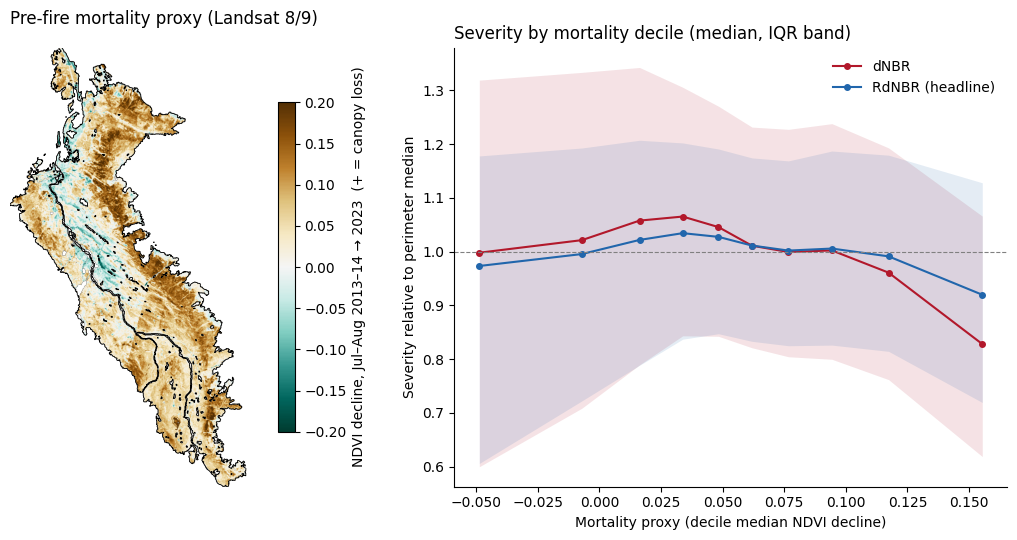

In [27]:
import matplotlib.pyplot as plt

df["mort_dec"] = pd.qcut(df.mort, 10, labels=False)          # recompute after the |NBR_pre| filter
q = lambda p: (lambda s: s.quantile(p))
dec = df.groupby("mort_dec").agg(mort=("mort", "median"),
        **{f"{k}_{p}": (k, q(p)) for k in ("dnbr", "rdnbr") for p in (0.25, 0.5, 0.75)})

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.15, 1]})
m = mort.where(IN & veg)
im = a1.imshow(m.values, cmap="BrBG_r", vmin=-0.2, vmax=0.2,
               extent=[float(m.x.min()) - 10, float(m.x.max()) + 10, float(m.y.min()) - 10, float(m.y.max()) + 10])
perim.boundary.plot(ax=a1, color="k", lw=0.6)
x0, y0, x1, y1 = perim.total_bounds; a1.set_xlim(x0, x1); a1.set_ylim(y0, y1); a1.set_axis_off()
fig.colorbar(im, ax=a1, shrink=0.75, label="NDVI decline, Jul–Aug 2013–14 → 2023  (+ = canopy loss)")
a1.set_title("Pre-fire mortality proxy (Landsat 8/9)", loc="left")

for k, c, lab in [("dnbr", "#b2182b", "dNBR"), ("rdnbr", "#2166ac", "RdNBR (headline)")]:
    med = df[k].median()
    a2.plot(dec.mort, dec[f"{k}_0.5"] / med, "-o", color=c, label=lab, ms=4)
    a2.fill_between(dec.mort, dec[f"{k}_0.25"] / med, dec[f"{k}_0.75"] / med, color=c, alpha=0.12, lw=0)
a2.axhline(1, color="0.5", lw=0.8, ls="--")
a2.set_xlabel("Mortality proxy (decile median NDVI decline)")
a2.set_ylabel("Severity relative to perimeter median")
a2.set_title("Severity by mortality decile (median, IQR band)", loc="left")
a2.legend(frameon=False); a2.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIG / "beetle_severity.png", dpi=200, bbox_inches="tight")

06. Sentinel-2 robustness check

In [28]:
def block_rho(x, y, blk):
    g = pd.DataFrame({"x": x, "y": y, "blk": blk}).groupby("blk").agg(
        x=("x", "median"), y=("y", "median"), n=("x", "size"))
    g = g[g.n >= 1250]
    r = spearmanr(g.x, g.y)
    return r.statistic, r.pvalue, len(g)

def s2_ndvi(ic):
    st = stackstac.stack(ic, assets=["B04", "B08"], resampling=Resampling.bilinear, dtype="float32",
                         fill_value=np.float32(np.nan), rescale=False, **GRID)
    scl = stackstac.stack(ic, assets=["SCL"], resampling=Resampling.nearest, dtype="uint8",
                          fill_value=np.uint8(0), rescale=False, **GRID).sel(band="SCL")
    off = xr.where(st.coords["s2:processing_baseline"].astype(float) >= 4.0, 1000.0, 0.0)
    ok = scl.isin([2, 4, 5, 6, 7]) & (st > 0).all("band")
    red, nir = (st.sel(band=b) - off for b in ("B04", "B08"))
    v = ((nir - red) / (nir + red)).where(ok).chunk(time=-1)
    out = xr.Dataset({"ndvi": v.median("time", skipna=True), "n_clear": ok.sum("time")}).compute()
    return out.reset_coords(drop=True)

for yr in (2016, 2017, 2018):
    ic = cat.search(collections=["sentinel-2-l2a"], bbox=BBOX, datetime=f"{yr}-07-01/{yr}-08-31",
                    query={"s2:mgrs_tile": {"eq": "11UMU"}}).item_collection()
    if len(ic) == 0:
        print(yr, "no scenes"); continue
    s2e = s2_ndvi(ic)
    zc = ((s2e.n_clear.values == 0) & IN).sum() / IN.sum()
    print(f"{yr}: {len(ic)} scenes, perimeter zero-clear {zc:.1%}")
    if zc <= 0.05:
        break
S2_YEAR = yr

mort_s2 = s2e.ndvi.values - ndvi(pre).values
keep = df.index                                                  # same pixels as the Landsat test
flat = np.flatnonzero(sel)
x_s2 = mort_s2.ravel()[flat][keep] if isinstance(keep, pd.RangeIndex) else mort_s2[sel][keep.values]
ok_s2 = np.isfinite(x_s2)
print(f"Landsat vs S2 proxy agreement: rho {spearmanr(df.mort[ok_s2], x_s2[ok_s2]).statistic:.3f}")
for k in ("dnbr", "rdnbr"):
    r, p, n = block_rho(x_s2[ok_s2], df[k][ok_s2], df.blk[ok_s2])
    print(f"S2 {S2_YEAR}→2023 proxy vs {k}: 1 km blocks rho {r:.3f}, p={p:.2g} (n={n})")

/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


2016: 5 scenes, perimeter zero-clear 12.2%


/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


2017: 11 scenes, perimeter zero-clear 0.0%
Landsat vs S2 proxy agreement: rho 0.362
S2 2017→2023 proxy vs dnbr: 1 km blocks rho 0.206, p=0.00018 (n=327)
S2 2017→2023 proxy vs rdnbr: 1 km blocks rho 0.282, p=2.2e-07 (n=327)


6b. early vs late decline

In [30]:
items["2017"] = search("2017-07-01/2017-08-31")
ls["2017"] = ndvi_composite(items["2017"])
zc = ((ls["2017"].n_clear.values == 0) & IN).sum() / IN.sum()
print(f"Landsat 2017: {len(items['2017'])} scenes, perimeter zero-clear {zc:.1%}")

idx = df.index.values                                         # positions within the sel pixel set
early = (ls["base"].ndvi - ls["2017"].ndvi).values[sel][idx]
late  = (ls["2017"].ndvi - ls["2023"].ndvi).values[sel][idx]
fin = np.isfinite(early) & np.isfinite(late)
print(f"Landsat late vs S2 2017→2023 proxy: rho {spearmanr(late[fin & ok_s2], x_s2[fin & ok_s2]).statistic:.3f}")
for name, x in [("early 2013-14→2017", early), ("late 2017→2023", late)]:
    for k in ("dnbr", "rdnbr"):
        r, p, n = block_rho(x[fin], df[k].values[fin], df.blk.values[fin])
        print(f"Landsat {name} vs {k}: 1 km blocks rho {r:.3f}, p={p:.2g} (n={n})")

/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


Landsat 2017: 13 scenes, perimeter zero-clear 3.9%
Landsat late vs S2 2017→2023 proxy: rho 0.482
Landsat early 2013-14→2017 vs dnbr: 1 km blocks rho -0.125, p=0.027 (n=317)
Landsat early 2013-14→2017 vs rdnbr: 1 km blocks rho -0.058, p=0.31 (n=317)
Landsat late 2017→2023 vs dnbr: 1 km blocks rho -0.062, p=0.27 (n=317)
Landsat late 2017→2023 vs rdnbr: 1 km blocks rho -0.012, p=0.83 (n=317)


7. Save outputs

In [34]:
rows = []
for proxy, x, m_ok in [("Landsat 2013-14→2023", df.mort.values, np.ones(len(df), bool)),
                         ("Landsat 2013-14→2017", early, fin),
                         ("Landsat 2017→2023", late, fin),
                         (f"S2 {S2_YEAR}→2023", x_s2, ok_s2)]:
    for k in ("dnbr", "rdnbr"):
        r, p, n = block_rho(x[m_ok], df[k].values[m_ok], df.blk.values[m_ok])
        rows.append(dict(proxy=proxy, severity=k, rho_pixel=spearmanr(x[m_ok], df[k].values[m_ok]).statistic,
                         rho_1km=r, p_1km=p, n_blocks=n))
summary = pd.DataFrame(rows).round(4)
summary.to_csv(FIG / "beetle_severity_summary.csv", index=False)
dec.round(4).to_csv(FIG / "beetle_severity_deciles.csv")
summary

,proxy,severity,rho_pixel,rho_1km,p_1km,n_blocks
0,Landsat 2013-14→2023,dnbr,-0.0934,-0.1825,0.0009,327
1,Landsat 2013-14→2023,rdnbr,-0.0005,-0.0839,0.1300,327
2,Landsat 2013-14→2017,dnbr,-0.0883,-0.1246,0.0265,317
3,Landsat 2013-14→2017,rdnbr,-0.0215,-0.0576,0.3064,317
4,Landsat 2017→2023,dnbr,0.0037,-0.0622,0.2693,317
5,Landsat 2017→2023,rdnbr,0.0287,-0.0120,0.8314,317
6,S2 2017→2023,dnbr,0.1218,0.2060,0.0002,327
7,S2 2017→2023,rdnbr,0.1732,0.2820,0.0000,327
